<div align="left">
    <img src="Escudo_uaustralchile.png" width="300">
</div>

# Estudio y análisis de los diferentes sistemas de amortiguamiento

### Matías Muñoz
### José Henríquez

### Importar librerías

In [1]:
# Importar librerías
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

print("Ambiente listo para análisis de vibraciones")

Ambiente listo para análisis de vibraciones


# Tabla de contenido
- Introduccion, Modelo fisico general
- Sistema Masa Resorte amortiguado
- Decremento Logaritmico
- Funciones de transferencia
- admitancia


## 1. Modelo Físico General

El punto de partida para el análisis dinámico es la ecuación de movimiento con excitación externa $f(t)$:
<div align="left">
    <img src="3.png" width="300">
</div>

$$m\ddot{x}(t) + kx(t) = f(t)$$

**Estudio de la Vibración Libre ($f(t) = 0$):**

Para entender la frecuencia natural del sistema, Pensamos en el caso sin excitacion externa. Al establecer $f(t) = 0$, la expresión se convierte en la ecuación de vibración libre no amortiguada, permitiendo evaluar cómo responde el sistema basándose solo en su masa y su rigidez:

$$m\ddot{x}(t) + kx(t) = 0$$

## 2. Parámetros del sistema

La **frecuencia natural angular** del sistema no amortiguado se expresa como:

$
\omega_n = \sqrt{\frac{k}{m}}
$

donde $\omega_n$ se mide en:

$
\text{rad/s}
$

Para expresar la frecuencia en ciclos por segundo, usamos la **frecuencia natural en Hertz**:

$
f_n = \frac{\omega_n}{2\pi}
$

donde $f_n$ se mide en:

$
\text{Hz}
$

 $\omega_n$ y $f_n$ representan la misma frecuencia natural del sistema, pero expresada en unidades distintas

In [2]:
# 2. Definir parámetros físicos

m = 1.0       # masa [kg]
k = 100.0     # rigidez [N/m]

wn = np.sqrt(k / m)       # frecuencia natural angular [rad/s]
fn = wn / (2 * np.pi)     # frecuencia natural [Hz]
Tn = 1 / fn               # periodo natural [s]

print(f"Frecuencia natural angular wn = {wn:.1f} rad/s")
print(f"Frecuencia natural fn = {fn:.1f} Hz")
print(f"Periodo natural Tn = {Tn:.1f} s")

Frecuencia natural angular wn = 10.0 rad/s
Frecuencia natural fn = 1.6 Hz
Periodo natural Tn = 0.6 s


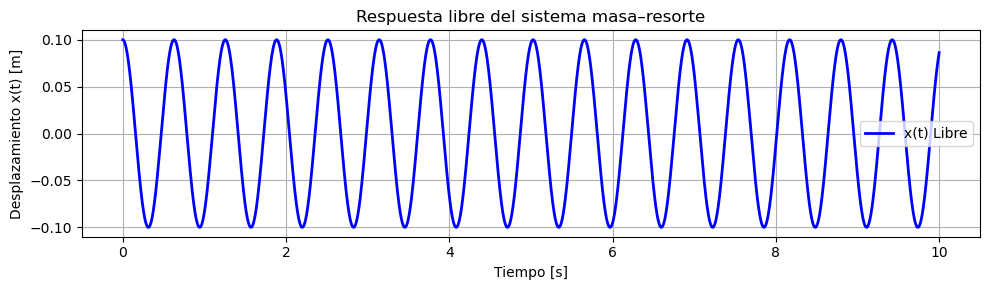

In [3]:
# 3. Respuesta libre analítica

x0 = 0.10     # desplazamiento inicial [m]
v0 = 0.00     # velocidad inicial [m/s]

# --- CAMBIO CLAVE: Aumentamos el tiempo a 50 segundos para que la FFT funcione impecable ---
t = np.linspace(0, 10, 5000) 

x_libre = x0 * np.cos(wn * t) + (v0 / wn) * np.sin(wn * t)

# --- SOLUCIÓN TÉCNICA PARA VS CODE ---
plt.ioff()          # Desactivamos modo interactivo un segundo para resetear
plt.close('all')    # Cerramos cualquier residuo de gráficos fantasmas de la FFT
# -------------------------------------

# Creamos una figura completamente limpia y nueva
fig, ax = plt.subplots(figsize=(10, 3))

ax.plot(t, x_libre, color='blue', linewidth=2, label='x(t) Libre')
ax.set_title("Respuesta libre del sistema masa–resorte")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Desplazamiento x(t) [m]")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show() # ¡Este es el que manda a pintar la pantalla!

## Análisis en el Dominio de la Frecuencia (FFT)

Al graficar la respuesta temporal de la vibración libre, observamos una oscilación armónica pura. Para identificar con precisión la frecuencia dominante del sistema, transformamos la señal del dominio del tiempo al dominio de la frecuencia mediante la **Transformada Rápida de Fourier (FFT)**.



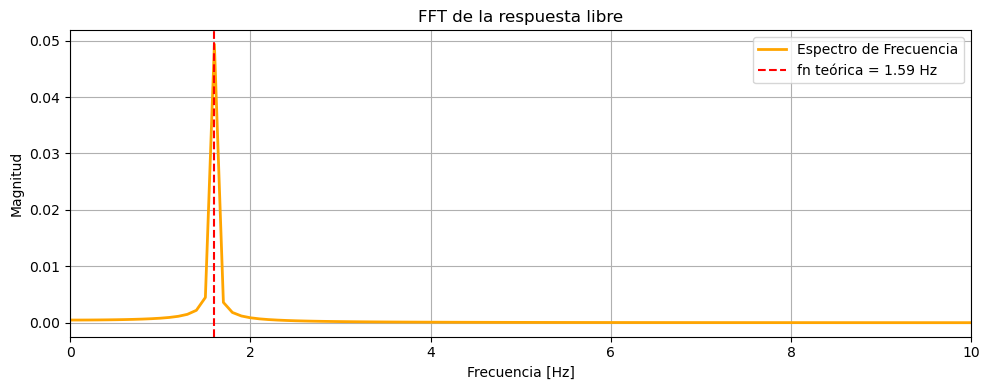

In [4]:
# 4. FFT de la respuesta libre (Versión corregida anti-desfase de celdas)
from scipy.fft import fft, fftfreq  # O de 'numpy.fft', la que estés usando

dt = t[1] - t[0]
N = len(x_libre) 

X = fft(x_libre)
freq = fftfreq(N, dt)

mask = freq >= 0
freq_pos = freq[mask]
X_mag = np.abs(X[mask]) / N

plt.figure(figsize=(10, 4))
plt.plot(freq_pos, X_mag, color='orange', linewidth=2, label='Espectro de Frecuencia')
plt.axvline(fn, color='red', linestyle="--", label=f"fn teórica = {fn:.2f} Hz")
plt.title("FFT de la respuesta libre")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(0, 10)  
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

<div align="right">
    </div>

### Conclusión 
Como el sistema es ideal y **no posee amortiguamiento**, la FFT nos muestra que el 100% de la energía térmica y cinética se concentra en la **frecuencia natural ($\omega_n$)**. 

* **El problema real:** En las estructuras reales, esta energía se disipa y el pico se deforma. Esto nos obliga a incorporar el concepto de **amortiguamiento viscoso** (que mediremos con el *Decremento Logarítmico*) y a estudiar cómo responde el sistema ante cualquier frecuencia de excitación (a través de las *Funciones de Transferencia y Admitancia*).

## 3. Respuesta Forzada y el Fenómeno de Resonancia

Hasta ahora vimos que el sistema oscila libremente a su frecuencia natural ($f_n = 1.59$ Hz). ¿Pero qué ocurre si aplicamos una fuerza externa armónica $f(t) = F_0 \sin(\omega t)$ que empuja la masa de forma continua a una **frecuencia de excitación ($f$)** variable?

En lugar de analizar las ondas en el tiempo, transformamos el sistema al dominio de la frecuencia mediante la FFT para observar la **magnitud de la respuesta**. 

Mueve el deslizador a continuación para aproximar la frecuencia de excitación ($f$) a la frecuencia natural del sistema ($f_n = 1.59$ Hz). Observa cómo al igualarse las frecuencias, la energía del sistema se amplifica drásticamente: esto es la **Resonancia**.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
import warnings

# Bloquear advertencias de sintaxis de LaTeX en las gráficas de VS Code
warnings.filterwarnings('ignore', category=SyntaxWarning)

# ==========================================
# 1. PARAMETROS FÍSICOS CONSTANTES DEL SISTEMA
# ==========================================
m = 1.0       # masa [kg]
k = 100.0     # rigidez [N/m]
wn = np.sqrt(k / m)
fn_teorica = wn / (2 * np.pi)  # 1.59 Hz

# Vector de tiempo continuo para el gráfico inferior (Dominio del Tiempo)
t_eje = np.linspace(0, 15, 1500)

# ==========================================
# 2. FUNCIÓN INTERACTIVA COMPARATIVA SÍNCRONA
# ==========================================
def graficar_sistema_forzado_fiel(f_excitacion, zeta):
    w_excitacion = 2 * np.pi * f_excitacion
    F0 = 1.0  # Amplitud de la fuerza externa [N]
    
    # --- DOMINIO DE LA FRECUENCIA (Cálculo Analítico de la FRF) ---
    # c = 2 * zeta * m * wn
    # H(w) = 1 / ((k - m*w^2) + j*(c*w))
    c = 2 * zeta * m * wn
    real_den = k - m * (w_excitacion**2)
    imag_den = c * w_excitacion
    
    # Evitar indeterminación matemática pura si zeta es 0 en resonancia exacta
    if abs(real_den) < 1e-3 and imag_den == 0:
        real_den = 1e-3
        
    # Magnitud y Fase de la respuesta estacionaria
    magnitud_X = F0 / np.sqrt(real_den**2 + imag_den**2)
    fase = -np.arctan2(imag_den, real_den)
    
    # --- DOMINIO DEL TIEMPO ---
    # Onda limpia en estado permanente adoptando la frecuencia exacta de la fuerza
    x_t = magnitud_X * np.sin(w_excitacion * t_eje + fase)
    
    # ==========================================
    # 3. CONFIGURACIÓN DE LOS GRÁFICOS (2x1)
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7))
    
    # ------------------------------------------
    # GRÁFICO 1: Dominio de la Frecuencia (FRF Espectro Continuo)
    # ------------------------------------------
    # Generamos el barrido de frecuencias para dibujar la curva base
    f_barrido = np.linspace(0.1, 3.0, 1000)
    w_barrido = 2 * np.pi * f_barrido
    curva_frf = F0 / np.sqrt((k - m * (w_barrido**2))**2 + (2 * zeta * m * wn * w_barrido)**2)
    
    ax1.plot(f_barrido, curva_frf, color='orange', linewidth=2.5, label='Curva de Admitancia $|H(f)|$')
    ax1.axvline(fn_teorica, color='red', linestyle='--', linewidth=1.5, label=f'fn Natural ({fn_teorica:.2f} Hz)')
    ax1.axvline(f_excitacion, color='purple', linestyle='-', linewidth=2, label=f'f de Excitación Actual ({f_excitacion:.2f} Hz)')
    
    # El punto de operación exacto amarrado por imán a la intersección
    ax1.plot(f_excitacion, magnitud_X, 'ro', markersize=9, label=f'Respuesta Actual ({magnitud_X:.3f} m)')
    
    ax1.set_title('Dominio de la Frecuencia: Espectro Continuo de la Respuesta (FRF)', fontsize=12)
    ax1.set_xlabel('Frecuencia [Hz]')
    ax1.set_ylabel('Magnitud de Desplazamiento $|X|$ [m]')
    ax1.set_xlim(0, 3)
    
    # Ajuste de escala dinámico para que no se desarme el gráfico en resonancia
    if zeta < 0.04:
        ax1.set_ylim(0, 0.5)
    else:
        ax1.set_ylim(0, np.max(curva_frf) * 1.3)
        
    ax1.grid(True, linestyle=':')
    ax1.legend(loc='upper right')
    
    # ------------------------------------------
    # GRÁFICO 2: Dominio del Tiempo (Respuesta Estacionaria)
    # ------------------------------------------
    ax2.plot(t_eje, x_t, color='blue', linewidth=1.5, alpha=0.8)
    ax2.set_title('Dominio del Tiempo: Desplazamiento Estable $x(t) = |X| \sin(\omega t + \phi)$', fontsize=12)
    ax2.set_xlabel('Tiempo [s]')
    ax2.set_ylabel('x(t) [m]')
    ax2.set_xlim(0, 15)
    
    # Mantiene la simetría del eje temporal según la amplitud calculada
    ax2.set_ylim(-max(0.1, magnitud_X * 1.2), max(0.1, magnitud_X * 1.2))
    ax2.grid(True, linestyle=':')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. CREACIÓN DE LOS SLIDERS INTERACTIVOS DOBLES
# ==========================================
interact(
    graficar_sistema_forzado_fiel, 
    f_excitacion=FloatSlider(
        value=0.5, 
        min=0.2, 
        max=3.0, 
        step=0.02, 
        description='Frecuencia [Hz]:',
        continuous_update=True,
        layout={'width': '500px'}
    ),
    zeta=FloatSlider(
        value=0.05, 
        min=0.01, # Partimos de un amortiguamiento mínimo real para evitar errores
        max=0.4, 
        step=0.01, 
        description='Amortig. ($\zeta$):',
        continuous_update=True,
        layout={'width': '500px'}
    )
)

interactive(children=(FloatSlider(value=0.5, description='Frecuencia [Hz]:', layout=Layout(width='500px'), max…

<function __main__.graficar_sistema_forzado_fiel(f_excitacion, zeta)>

## 4. Incorporación del Amortiguamiento Viscoso 

Para evitar el colapso infinito por resonancia, los sistemas reales disipan energía mediante fricción o fluidos. El modelo más utilizado es el **Amortiguamiento Viscoso Lineal**, donde la fuerza disipativa es proporcional a la velocidad: $f_c = c \cdot \dot{x}(t)$.

La nueva ecuación diferencial que gobierna el sistema de un grado de libertad (1-DOF) es:

$$m\ddot{x}(t) + c\dot{x}(t) + kx(t) = 0$$

Dividiendo por la masa ($m$), obtenemos la expresión normalizada estándar de la acústica y vibraciones:

$$\ddot{x}(t) + 2\zeta\omega_n\dot{x}(t) + \omega_n^2x(t) = 0$$

Donde introducemos la **Razón de Amortiguamiento ($\zeta$)**, un parámetro adimensional crítico:

$$\zeta = \frac{c}{2\sqrt{km}} = \frac{c}{2m\omega_n}$$

### Regímenes de Amortiguamiento según $\zeta$:
1. **Sub-amortiguado ($0 < \zeta < 1$):** El sistema oscila, pero su amplitud decae exponencialmente. Es el caso de mayor interés práctico y el que estudiaremos a continuación.
2. **Críticamente amortiguado ($\zeta = 1$):** El sistema regresa al equilibrio lo más rápido posible sin oscilar.
3. **Sobre-amortiguado ($\zeta > 1$):** El sistema es extremadamente lento para volver al reposo debido a la alta fricción.

## 5. El Método del Decremento Logarítmico

El **Decremento Logarítmico ($\delta$)** es un método experimental que permite estimar la razón de amortiguamiento ($\zeta$) de una estructura midiendo la tasa de decaimiento de dos picos máximos sucesivos ($x_0$ y $x_1$) separados por un periodo amortiguado $T_d$.

Se define matemáticamente como:

$$\delta = \ln\left(\frac{x_0}{x_1}\right) = \frac{2\pi\zeta}{\sqrt{1-\zeta^2}}$$

### Extensión para $n$ Ciclos (Mitigación de Ruido)
En mediciones reales, el ruido de fondo puede alterar la altura de un pico. Para asegurar la precisión, medimos la amplitud del primer pico ($x_0$) y la de un pico situado $n$ ciclos después ($x_n$):

$$\delta = \frac{1}{n} \ln\left(\frac{x_0}{x_n}\right)$$

Una vez obtenido $\delta$ experimentalmente, despejamos de forma exacta nuestra razón de amortiguamiento:

$$\zeta = \frac{\delta}{\sqrt{4\pi^2 + \delta^2}}$$

In [6]:
# Parámetros físicos del sistema
mass = 10.0          # kg masa
stiffness = 4000.0   # N/m Rigidez del resorte
damping_ratio = 0.03 # 3% factor de amortiguamiento

# Parámetros de simulación
sampling_frequency = 200.0 # Hz frecuencia de muestreo
duration = 20.0            # seconds tiempo total de la simulación
initial_displacement = 0.01 # m posición inicial

# Frecuencia natural
omega_n = np.sqrt(stiffness / mass)      # rad/s frecuencia angular
fn_hz = omega_n / (2 * np.pi)            # Hz convierte

# Frecuencia natural amortiguada
omega_d = omega_n * np.sqrt(1 - damping_ratio**2)
fd_hz = omega_d / (2 * np.pi)

print(f"Frecuencia natural no amortiguada fn = {fn_hz:.3f} Hz")
print(f"Frecuencia natural amortiguada fd = {fd_hz:.3f} Hz")

Frecuencia natural no amortiguada fn = 3.183 Hz
Frecuencia natural amortiguada fd = 3.182 Hz


## Generar la respuesta temporal

Para una vibración libre amortiguada, una forma simple de la respuesta es:

$
x(t) = x_0 e^{-\zeta \omega_n t}\cos(\omega_d t)
$

donde:

- $x_0$ es el desplazamiento inicial;
- $\zeta$ es la razón de amortiguamiento;
- $\omega_n$ es la frecuencia natural angular;
- $\omega_d$ es la frecuencia angular amortiguada.

Además, agregaremos un poco de ruido para simular una medición experimental.

In [7]:
rng = np.random.default_rng(42)

t = np.arange(0, duration, 1 / sampling_frequency)

x_clean = initial_displacement * np.exp(-damping_ratio * omega_n * t) * np.cos(omega_d * t)

noise_std = 0.02
noise = rng.normal(
    loc=0.0,
    scale=noise_std * np.max(np.abs(x_clean)),
    size=len(t)
)

x_noisy = x_clean + noise

print(f"Número de muestras: {len(t)}")
print(f"Duración: {duration} s")
print(f"Frecuencia de muestreo: {sampling_frequency} Hz")

Número de muestras: 4000
Duración: 20.0 s
Frecuencia de muestreo: 200.0 Hz


## 4 Estimar la densidad espectral de potencia

La densidad espectral de potencia, PSD, permite observar cómo se distribuye la energía de la señal en frecuencia.

Para estimarla usaremos el método de Welch.

In [8]:
frequencies, psd = welch(
    x_noisy,
    fs=sampling_frequency,
    nperseg=1024,
    noverlap=512
)

dominant_frequency = frequencies[np.argmax(psd)]

print(f"Frecuencia natural teórica: {fn_hz:.3f} Hz")
print(f"Frecuencia dominante estimada desde PSD: {dominant_frequency:.3f} Hz")

Frecuencia natural teórica: 3.183 Hz
Frecuencia dominante estimada desde PSD: 3.125 Hz


Frecuencia natural teórica: 3.183 Hz
Frecuencia dominante estimada desde PSD: 3.125 Hz


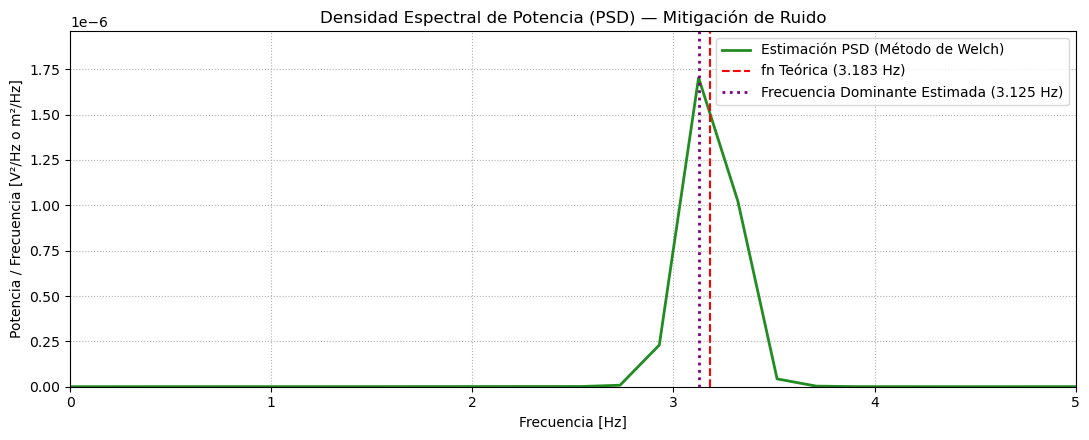

In [9]:
frequencies, psd = welch(
    x_noisy,
    fs=sampling_frequency,
    nperseg=1024,
    noverlap=512
)

dominant_frequency = frequencies[np.argmax(psd)]

print(f"Frecuencia natural teórica: {fn_hz:.3f} Hz")
print(f"Frecuencia dominante estimada desde PSD: {dominant_frequency:.3f} Hz")# ========================================================
# 5. Gráfico de la Densidad Espectral de Potencia (PSD)
# ========================================================
plt.figure(figsize=(11, 4.5))

# Graficamos la PSD estimada con Welch
plt.plot(frequencies, psd, color='forestgreen', linewidth=2, label='Estimación PSD (Método de Welch)')

# Línea vertical en la frecuencia natural teórica (la meta)
plt.axvline(fn_hz, color='red', linestyle='--', linewidth=1.5, 
            label=f'fn Teórica ({fn_hz:.3f} Hz)')

# Línea vertical en el pico máximo que encontró el script
plt.axvline(dominant_frequency, color='purple', linestyle=':', linewidth=2, 
            label=f'Frecuencia Dominante Estimada ({dominant_frequency:.3f} Hz)')

# Configuración estética y títulos
plt.title('Densidad Espectral de Potencia (PSD) — Mitigación de Ruido', fontsize=12)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia / Frecuencia [V²/Hz o m²/Hz]')

# ZOOM EJE X: Ajustamos el límite para centrarnos en la zona baja donde está la física del sistema
plt.xlim(0, 5) 
plt.ylim(0, np.max(psd) * 1.15) # Le damos un 15% de aire arriba al pico para que se vea holgado

plt.grid(True, linestyle=':')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [11]:
rng = np.random.default_rng(42)

t = np.arange(0, duration, 1 / sampling_frequency)

x_clean = initial_displacement * np.exp(-damping_ratio * omega_n * t) * np.cos(omega_d * t)
x_clean1 = initial_displacement * np.exp(-damping_ratio1 * omega_n * t) * np.cos(omega_n * np.sqrt(1 - damping_ratio1**2) * t)
x_clean2 = initial_displacement * np.exp(-damping_ratio2 * omega_n * t) * np.cos(omega_n * np.sqrt(1 - damping_ratio2**2) * t)
x_clean3 = initial_displacement * np.exp(-damping_ratio3 * omega_n * t) * np.cos(omega_n * np.sqrt(1 - damping_ratio3**2) * t)
noise_std = 0.02
noise = rng.normal(
    loc=0.0,
    scale=noise_std * np.max(np.abs(x_clean)),
    size=len(t)
)
noise1 = rng.normal(
    loc=0.0,
    scale=noise_std * np.max(np.abs(x_clean1)),
    size=len(t)
)
noise2 = rng.normal(
    loc=0.0,
    scale=noise_std * np.max(np.abs(x_clean2)),
    size=len(t)
)
noise3 = rng.normal(
    loc=0.0,
    scale=noise_std * np.max(np.abs(x_clean3)),
    size=len(t)
)
x_noisy = x_clean + noise
x_noisy1 = x_clean1 + noise1
x_noisy2 = x_clean2 + noise2
x_noisy3 = x_clean3 + noise3

print(f"Número de muestras: {len(t)}")
print(f"Duración: {duration} s")
print(f"Frecuencia de muestreo: {sampling_frequency} Hz")

NameError: name 'damping_ratio1' is not defined

## ¿Por qué la frecuencia dominante estimada desde la PSD no coincide exactamente con la frecuencia teórica?
Esto se debe a que al momento de trabajar con PSD, estamos trabajando en un mundo digital, que se ve filtrado por la FFT. Si bien no son iguales, tienen valores bastante cercanos ya que la frecuencia teórica hace alusión a un sistema en el mundo real, mientras que el valor de la frecuencia dominante es del dominio digital distribuido en "cajas"
Podemos visualizar la diferencia entre las freciencias en el siguiente gráfico:

In [ ]:
frecuencies, psd = welch(
    x_noisy,
    fs=sampling_frequency,
    nperseg=1024,
    noverlap=512
)

dominant_frequency = frequencies[np.argmax(psd)]
print(f"Frecuencia natural teórica: {fn_hz:.3f} Hz")
print(f"Frecuencia dominante estimada desde PSD: {dominant_frequency:.3f} Hz")

Frecuencia natural teórica: 3.183 Hz
Frecuencia dominante estimada desde PSD: 3.125 Hz


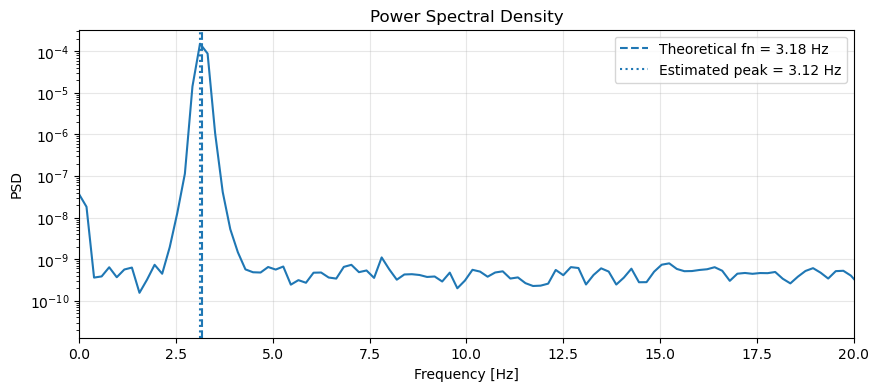

In [ ]:
plt.figure(figsize=(10, 4))
plt.semilogy(frequencies, psd)
plt.axvline(fn_hz, linestyle="--", label=f"Theoretical fn = {fn_hz:.2f} Hz")
plt.axvline(dominant_frequency, linestyle=":", label=f"Estimated peak = {dominant_frequency:.2f} Hz")
plt.title("Power Spectral Density")
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD")
plt.xlim(0, 20)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## ¿Por qué usamos el logaritmo del cociente entre amplitudes?

Ya que transforma un problema de curvas exponenciales dificiles de medir en una simple relación lineal que relaciona directamente la pérdida de altura de la onda con el porcentaje de amortiguamiento del sistema, esto lo podemos ver en el siguiente procedimiento:

In [ ]:
# Parámetros físicos del sistema
mass = 10.0          # kg
stiffness = 4000.0   # N/m
zeta_true = 0.04     # razón de amortiguamiento verdadera

# Parámetros de simulación
sampling_frequency = 200.0  # Hz
duration = 20.0             # s
initial_displacement = 0.01 # m

# Cálculos teóricos
omega_n = np.sqrt(stiffness / mass)
fn_hz = omega_n / (2 * np.pi)

omega_d = omega_n * np.sqrt(1 - zeta_true**2)
fd_hz = omega_d / (2 * np.pi)

c_true = 2 * zeta_true * mass * omega_n

print(f"Masa m = {mass:.2f} kg")
print(f"Rigidez k = {stiffness:.2f} N/m")
print(f"Razón de amortiguamiento verdadera zeta = {zeta_true:.4f}")
print(f"Frecuencia natural fn = {fn_hz:.3f} Hz")
print(f"Frecuencia amortiguada fd = {fd_hz:.3f} Hz")
print(f"Coeficiente de amortiguamiento verdadero c = {c_true:.3f} N s/m")

Masa m = 10.00 kg
Rigidez k = 4000.00 N/m
Razón de amortiguamiento verdadera zeta = 0.0400
Frecuencia natural fn = 3.183 Hz
Frecuencia amortiguada fd = 3.181 Hz
Coeficiente de amortiguamiento verdadero c = 16.000 N s/m


In [ ]:
rng = np.random.default_rng(42)

t = np.arange(0, duration, 1 / sampling_frequency)

x_clean = initial_displacement * np.exp(-zeta_true * omega_n * t) * np.cos(omega_d * t)

noise_level = 0.015
noise = rng.normal(
    loc=0.0,
    scale=noise_level * np.max(np.abs(x_clean)),
    size=len(t)
)

x_noisy = x_clean + noise

print(f"Número de muestras: {len(t)}")
print(f"Duración de la señal: {duration} s")
print(f"Frecuencia de muestreo: {sampling_frequency} Hz")

Número de muestras: 4000
Duración de la señal: 20.0 s
Frecuencia de muestreo: 200.0 Hz


Número de máximos positivos detectados: 66
Período amortiguado teórico aproximado: 0.314 s
Distancia mínima usada: 43 muestras


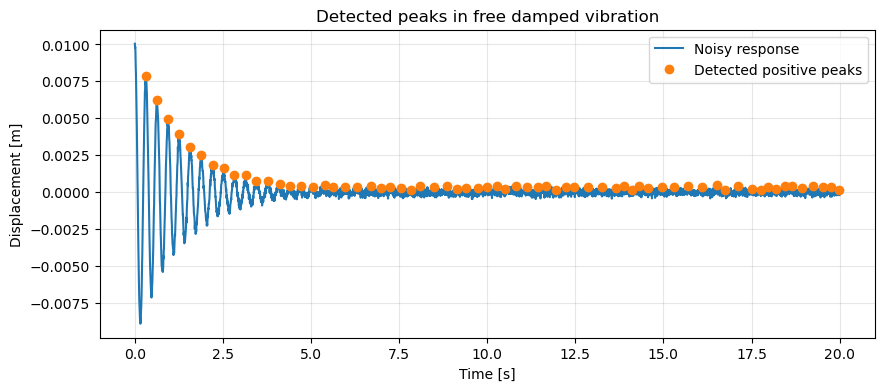

In [ ]:
# Distancia mínima esperada entre peaks
# Si la frecuencia amortiguada es fd_hz, el período amortiguado es aproximadamente 1/fd_hz.
# Convertimos ese período a muestras.
period_samples = int((1 / fd_hz) * sampling_frequency)

peaks, properties = find_peaks(
    x_noisy,
    distance=int(0.7 * period_samples),
    prominence=0.0002
)

peak_times = t[peaks]
peak_values = x_noisy[peaks]

# Nos quedamos solo con peaks positivos
positive_mask = peak_values > 0
peak_times = peak_times[positive_mask]
peak_values = peak_values[positive_mask]
peaks = peaks[positive_mask]

print(f"Número de máximos positivos detectados: {len(peak_values)}")
print(f"Período amortiguado teórico aproximado: {1/fd_hz:.3f} s")
print(f"Distancia mínima usada: {int(0.7 * period_samples)} muestras")
plt.figure(figsize=(10, 4))
plt.plot(t, x_noisy, label="Noisy response")
plt.plot(peak_times, peak_values, "o", label="Detected positive peaks")
plt.title("Detected peaks in free damped vibration")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## ¿Por qué puede ser conveniente usar peaks separados por varios ciclos?

Porque al usar estos peaks separados, el cálculo se hace más exacto, ya que si consideramos la siguiente fórmula:

$
\delta = \frac{1}{n}\ln\left(\frac{X_i}{X_{i+n}}\right)
$

donde n es el número de ciclos de separación, en vez de evaluar como se amortiguó el sistema, se evalúa como se comporta a lo largo de 4, 5 o 10 ciclos, lo que suaviza cualquier anomalía temporal.
En el ejemplo siguiente usaremos n=5

In [ ]:
# Selección de peaks para el cálculo
i = 0
n_cycles = 10
n_cycles1 = 1

if len(peak_values) <= n_cycles:
    raise ValueError("No hay suficientes peaks detectados para aplicar el decremento logarítmico.")
if len(peak_values) <= n_cycles1:
    raise ValueError("No hay suficientes peaks detectados para aplicar el decremento logarítmico con n_cycles1.")
x_i = peak_values[i]
x_i_n = peak_values[i + n_cycles]
x_i_n1 = peak_values[i + n_cycles1]
t_i = peak_times[i]
t_i_n = peak_times[i + n_cycles]
t_i_n1 = peak_times[i + n_cycles1]

delta_est = (1 / n_cycles) * np.log(x_i / x_i_n)
delta_est1 = (1 / n_cycles1) * np.log(x_i / x_i_n1)

zeta_est = delta_est / np.sqrt(4 * np.pi**2 + delta_est**2)
zeta_est1 = delta_est1 / np.sqrt(4 * np.pi**2 + delta_est1**2)

omega_n_est = omega_d / np.sqrt(1 - zeta_est**2)
c_est = 2 * zeta_est * mass * omega_n_est
omega_n_est1 = omega_d / np.sqrt(1 - zeta_est1**2)
c_est1 = 2 * zeta_est1 * mass * omega_n_est1

print("Estimación por decremento logarítmico")
print("--------------------------------------")
print(f"x_i = {x_i:.6f} m en t = {t_i:.3f} s")
print(f"x_i+n = {x_i_n:.6f} m en t = {t_i_n:.3f} s")
print(f"Número de ciclos n = {n_cycles}")
print(f"Decremento logarítmico delta = {delta_est:.5f}")
print(f"zeta estimado = {zeta_est:.5f}")
print(f"c estimado = {c_est:.3f} N s/m")
print(f"Decremento logarítmico delta1 = {delta_est1:.5f}")
print(f"zeta estimado1 = {zeta_est1:.5f}")
print(f"c estimado1 = {c_est1:.3f} N s/m")

Estimación por decremento logarítmico
--------------------------------------
x_i = 0.007860 m en t = 0.315 s
x_i+n = 0.000796 m en t = 3.435 s
Número de ciclos n = 10
Decremento logarítmico delta = 0.22901
zeta estimado = 0.03642
c estimado = 14.568 N s/m
Decremento logarítmico delta1 = 0.22776
zeta estimado1 = 0.03623
c estimado1 = 14.488 N s/m


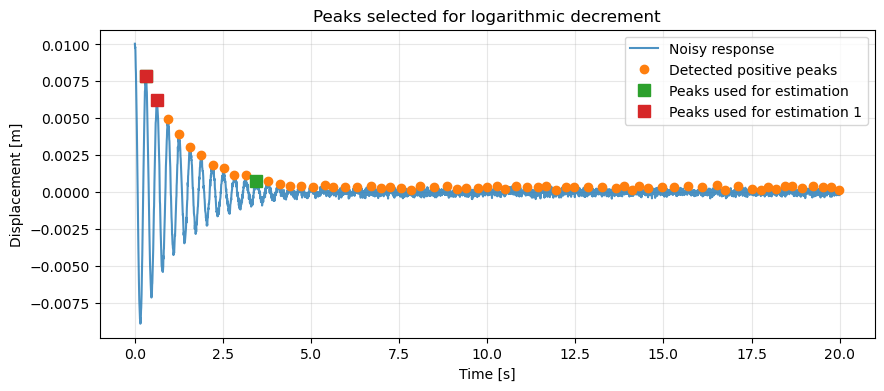

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(t, x_noisy, label="Noisy response", alpha=0.8)
plt.plot(peak_times, peak_values, "o", label="Detected positive peaks")
plt.plot([t_i, t_i_n], [x_i, x_i_n], "s", markersize=9, label="Peaks used for estimation")
plt.plot([t_i, t_i_n1], [x_i, x_i_n1], "s", markersize=9, label="Peaks used for estimation 1")
plt.title("Peaks selected for logarithmic decrement")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## ¿Qué problemas aparecen si la señal tiene mucho ruido?

Cuando aparece mucho ruido, nuestros métodos empiezan a fallar, ya que nuestro algoritmo empieza a detectar peaks que no corresponden a la señal de interés

In [ ]:
rng = np.random.default_rng(42)

t= np.arange(0, duration, 1 / sampling_frequency)

x_clean = initial_displacement * np.exp(-zeta_true * omega_n * t) * np.cos(omega_d * t)

realnoise_std = 0.25
realnoise = rng.normal(
    loc=0.0,
    scale=realnoise_std * np.max(np.abs(x_clean)),
    size=len(t)
)
x_realnoise = x_clean + realnoise



Número de máximos positivos detectados: 70
Período amortiguado teórico aproximado: 0.314 s
Distancia mínima usada: 43 muestras)


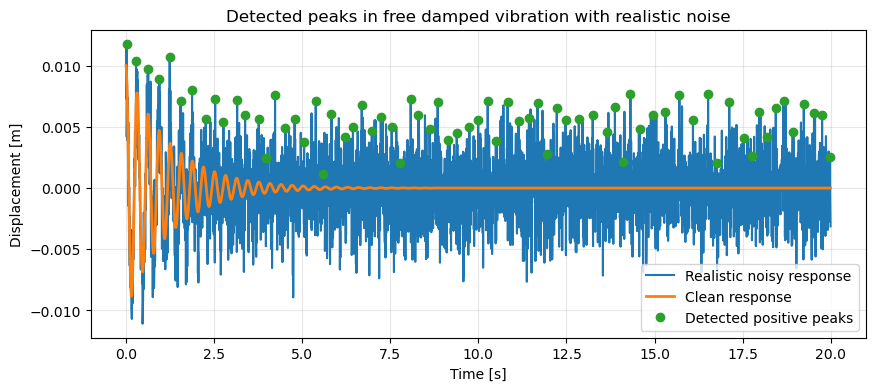

In [ ]:
period_samples = int((1 / fd_hz) * sampling_frequency)

peaks, properties = find_peaks(
    x_realnoise,
    distance=int(0.7 * period_samples),
    prominence=0.0002
)

peak_times = t[peaks]
peak_values = x_realnoise[peaks]

positive_mask = peak_values > 0
peak_times = peak_times[positive_mask]
peak_values = peak_values[positive_mask]
peaks = peaks[positive_mask]

print(f"Número de máximos positivos detectados: {len(peak_values)}")
print(f"Período amortiguado teórico aproximado: {1/fd_hz:.3f} s")
print(f"Distancia mínima usada: {int(0.7 * period_samples)} muestras)")
plt.figure(figsize=(10, 4))
plt.plot(t, x_realnoise, label="Realistic noisy response")
plt.plot(t, x_clean, linewidth=2, label="Clean response")
plt.plot(peak_times, peak_values, "o", label="Detected positive peaks")
plt.title("Detected peaks in free damped vibration with realistic noise")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

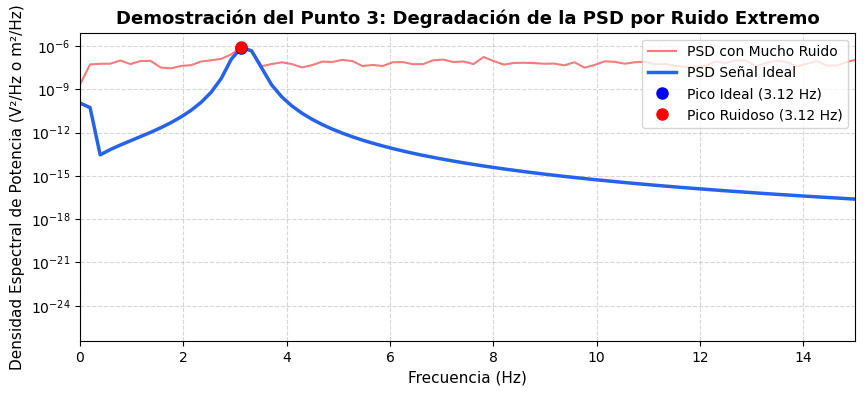

Frecuencia dominante ESTIMADA (Señal Limpia):  3.125 Hz
Frecuencia dominante ESTIMADA (Señal Ruidosa): 3.125 Hz


In [ ]:
from scipy import signal

# 1. Calcular la PSD para la señal limpia y la señal con mucho ruido
# Usamos el método de Welch con la frecuencia de muestreo de tu sistema
frecuencias_clean, psd_clean = signal.welch(x_clean, fs=sampling_frequency, nperseg=1024)
frecuencias_ruido, psd_ruido = signal.welch(x_realnoise, fs=sampling_frequency, nperseg=1024)

# 2. Encontrar numéricamente dónde está el pico máximo en cada caso
idx_max_clean = np.argmax(psd_clean)
f_dominante_clean = frecuencias_clean[idx_max_clean]

idx_max_ruido = np.argmax(psd_ruido)
f_dominante_ruido = frecuencias_ruido[idx_max_ruido]

# 3. Graficar ambas PSDs para compararlas
plt.figure(figsize=(10, 4))

# Graficamos la señal ruidosa primero (fondo)
plt.semilogy(frecuencias_ruido, psd_ruido, color="#ef4444", alpha=0.7, linewidth=1.5, label="PSD con Mucho Ruido")
# Graficamos la señal limpia (pico perfecto)
plt.semilogy(frecuencias_clean, psd_clean, color="#2563eb", linewidth=2.5, label="PSD Señal Ideal")

# Marcar los picos estimados en la gráfica
plt.plot(f_dominante_clean, psd_clean[idx_max_clean], "bo", markersize=8, label=f"Pico Ideal ({f_dominante_clean:.2f} Hz)")
plt.plot(f_dominante_ruido, psd_ruido[idx_max_ruido], "ro", markersize=8, label=f"Pico Ruidoso ({f_dominante_ruido:.2f} Hz)")

# Configuraciones de la gráfica
plt.title("Demostración del Punto 3: Degradación de la PSD por Ruido Extremo", fontsize=13, fontweight='bold')
plt.xlabel("Frecuencia (Hz)", fontsize=11)
plt.ylabel("Densidad Espectral de Potencia (V²/Hz o m²/Hz)", fontsize=11)
plt.xlim(0, 15)  # Hacemos zoom en las frecuencias bajas donde está nuestra física
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=10, loc="upper right")

plt.show()

# Print explicativo en consola
print("="*60)
print(f"Frecuencia dominante ESTIMADA (Señal Limpia):  {f_dominante_clean:.3f} Hz")
print(f"Frecuencia dominante ESTIMADA (Señal Ruidosa): {f_dominante_ruido:.3f} Hz")
print("="*60)

# Función de transferencia, admitancia y control dinámico

## Función de transferencia

Una función de transferencia consiste en un modelo matemático que relaciona directamente su salida con su entrada, como por ejemplo:


$
H(\omega)=\frac{X(\omega)}{F(\omega)}
$

## Admitancia

La admitancia es un tipo específico de función de transferencia que mide qué tan receptivo o fácil de mover es un sistema cuando se le aplica una fuerza, la cual se define como:

$
H(\omega)=\frac{1}{k-m\omega^2+jc\omega}
$

## Control dinámico

El control dinámico es un conjunto de técnicas, algorítmos y dispositivos mecánicos o electrónicos que se encargan de modificar o manipular la respuesta de un sistema para que se comporte de una manera segura y deseada, incluso en presencia de perturbaciones externas


In [ ]:
# Parámetros físicos
mass = 10.0          # kg
stiffness = 4000.0   # N/m
zeta = 0.04          # razón de amortiguamiento

# Frecuencia natural
omega_n = np.sqrt(stiffness / mass)
fn_hz = omega_n / (2 * np.pi)

# Coeficiente de amortiguamiento viscoso
c = 2 * zeta * mass * omega_n

print(f"Masa m = {mass:.2f} kg")
print(f"Rigidez k = {stiffness:.2f} N/m")
print(f"Razón de amortiguamiento zeta = {zeta:.4f}")
print(f"Coeficiente de amortiguamiento c = {c:.3f} N s/m")
print(f"Frecuencia natural fn = {fn_hz:.3f} Hz")

Masa m = 10.00 kg
Rigidez k = 4000.00 N/m
Razón de amortiguamiento zeta = 0.0400
Coeficiente de amortiguamiento c = 16.000 N s/m
Frecuencia natural fn = 3.183 Hz


# ¿Qué ocurre con el peak de resonancia si...? 

## Aumenta el amortiguamiento

Ocurren 3 cosas:

- La altura del peak va a ir disminuyendo
- El peak se ensancha, perdiendo selectividad o su factor de calidad
- La frecuencia de resonancia amortiguada tiende a moverse un poco hacia las bajas frecuencias

## Aumenta la rigidez

Se notarán 2 cosas:

- El peak de resonancia va a tender a ir a frecuencias más agudas
- El peak tenderá a ensancharse a la par de que va yendo a frencuencias agudas

## Aumento la masa


Se notarán 2 cosas:

- El peak de resonancia va a tender a ir a frecuencias más graves
- El peak de resonancia tenderá a volverse más centrado a medida que va yendo a frecuencias más graves

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# ==========================================================
# 1. CONFIGURACIÓN DEL VECTOR DE FRECUENCIAS
# ==========================================================
# Vector de frecuencias para evaluar la admitancia (eje X)
omega = np.linspace(0, 40, 1000)

# ==========================================================
# 2. FUNCIÓN DE ACTUALIZACIÓN DEL GRÁFICO GLOBAL
# ==========================================================
def simular_sistema_completo(k, m, c):
    # Calcular la admitancia H(w) compleja con los tres parámetros variables
    H = 1 / (k - m * omega**2 + 1j * c * omega)
    magnitud = np.abs(H)
    
    # Calcular la frecuencia natural teórica (wn = sqrt(k/m))
    omega_n = np.sqrt(k / m)
    
    # Calcular el factor de amortiguamiento adimensional (zeta)
    zeta = c / (2 * np.sqrt(k * m))
    
    # Calcular numéricamente la posición y altura del pico máximo real
    idx_max = np.argmax(magnitud)
    omega_pico_real = omega[idx_max]
    valor_pico_max = magnitud[idx_max]
    
    # Crear la figura
    plt.figure(figsize=(11, 5.5))
    
    # Graficar la curva de admitancia
    plt.plot(omega, magnitud, color='#0284c7', linewidth=2.5, label=r'Admitancia $|H(\omega)|$')
    
    # Línea horizontal: valor estático en baja frecuencia (1/k)
    plt.axhline(1/k, color='#ef4444', linestyle='--', alpha=0.7, 
                label=f'Respuesta Estática (1/k = {1/k:.4f})')
    
    # Línea vertical: frecuencia natural teórica (wn)
    plt.axvline(omega_n, color='#64748b', linestyle=':', linewidth=2, 
                label=f'Frecuencia Natural $\omega_n$ ({omega_n:.2f} rad/s)')
    
    # Marcar el punto del pico máximo con un punto rojo
    plt.plot(omega_pico_real, valor_pico_max, 'ro', markersize=8, 
             label=f'Pico de Resonancia Real ({omega_pico_real:.2f} rad/s)')
    
    # Configuraciones estéticas del gráfico
    plt.title(f'Simulador Dinámico de Admitancia Estructural\n'
              f'Rigidez ($k$) = {k:.1f} N/m  |  Masa ($m$) = {m:.2f} kg  |  Amortiguamiento ($c$) = {c:.2f} N·s/m\n'
              f'Factor de Amortiguamiento ($\zeta$) = {zeta:.3f}', 
              fontsize=11, fontweight='bold')
    plt.xlabel('Frecuencia de excitación de la fuerza $\omega$ (rad/s)', fontsize=10)
    plt.ylabel('Magnitud de la Admitancia |H($\omega$)| (m/N)', fontsize=10)
    
    # Límites fijos para poder observar los cambios de forma proporcional y realista
    plt.ylim(0, 0.15)
    plt.xlim(0, 40)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right', fontsize=9.5)
    
    plt.show()

# ==========================================================
# 3. CREACIÓN DE LOS TRES SLIDERS INTERACTIVOS
# ==========================================================
interact(simular_sistema_completo, 
    k=FloatSlider(
        value=200.0,   # Valor inicial de rigidez
        min=50.0,      # Estructura muy flexible / blanda
        max=600.0,     # Estructura muy rígida
        step=10.0,
        description='Rigidez (k):'
    ),
    m=FloatSlider(
        value=2.0,     # Valor inicial de masa
        min=0.5,       # Estructura muy liviana
        max=8.0,       # Estructura muy pesada
        step=0.1,
        description='Masa (m):'
    ),
    c=FloatSlider(
        value=1.5,     # Valor inicial de amortiguamiento
        min=0.2,       # Casi sin amortiguamiento (pico destructivo)
        max=15.0,      # Sistema altamente amortiguado
        step=0.1,
        description='Amortiguador (c):'
    )
);

interactive(children=(FloatSlider(value=200.0, description='Rigidez (k):', max=600.0, min=50.0, step=10.0), Fl…

## Conclusion
Podemos notar como los sistemas masa amortiguados estan en practicamente en todo al nuestro alrededor. Poder estudiar y entender el comportamiento de estos sistemas nos permite prevenir desde errores pequeños hasta catastrofes, por lo que es muy importante para el mundo en que vivimos hoy
